# Installations

In [ ]:
! apt-get install openjdk-8-jdk-headless -qq > /dev/null
! wget -q https://archive.apache.org/dist/spark/spark-3.5.4/spark-3.5.4-bin-hadoop3.tgz
! tar xf spark-3.5.4-bin-hadoop3.tgz
! pip install -q pyspark findspark

E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/universe/o/openjdk-8/openjdk-8-jre-headless_8u442-b06%7eus1-0ubuntu1%7e22.04_amd64.deb  404  Not Found [IP: 185.125.190.83 80]
E: Failed to fetch http://security.ubuntu.com/ubuntu/pool/universe/o/openjdk-8/openjdk-8-jdk-headless_8u442-b06%7eus1-0ubuntu1%7e22.04_amd64.deb  404  Not Found [IP: 185.125.190.83 80]
E: Unable to fetch some archives, maybe run apt-get update or try with --fix-missing?

gzip: stdin: unexpected end of file
tar: Unexpected EOF in archive
tar: Unexpected EOF in archive
tar: Error is not recoverable: exiting now


In [ ]:
! du -sh spark-3.5.4-bin-hadoop3.tgz

167M	spark-3.5.4-bin-hadoop3.tgz


In [ ]:
import os
os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
os.environ["SPARK_HOME"] = "/content/spark-3.5.4-bin-hadoop3"

In [ ]:
import findspark
findspark.init()

Exception: Unable to find py4j in /content/spark-3.5.4-bin-hadoop3/python, your SPARK_HOME may not be configured correctly

In [ ]:
import pyspark as spark
print(spark.__version__)

3.5.1


# Data Preparation

In [ ]:
import pyspark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, lag, window, date_format
from pyspark.ml.functions import vector_to_array
from pyspark.sql.window import Window
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
class DataProcessor():
  def __init__(self, app_name):
    self.spark = SparkSession.builder.appName(app_name).getOrCreate()
    self.df = None

  def load_from_csv(self, filename):
    if filename.split(".")[-1] != "csv":
      print("The provided file wasn't csv. Try another one")
      return;

    self.df = self.spark.read.csv(filename, header=True, inferSchema=True).cache() # enhance performance

  def generate_samples(self, target_col, num_cpd, window_spec_key):
      if not self.df:
        print("DataFrame doesn't exist, Try calling [load_from_csv()]")
        return None;

      window_spec = Window.orderBy(window_spec_key)
      temp_df = self.df.orderBy(window_spec_key).cache()
      for i in range(1, num_cpd + 1):
        temp_df = temp_df.withColumn(f"lag_{i}", lag(col(target_col), i).over(window_spec))
      temp_df = temp_df.na.drop(subset=[f"lag_{i}" for i in range(1, num_cpd + 1)])

      features = [f"lag_{i}" for i in range(1, num_cpd + 1)]

      # Assemble features into a vector column
      assembler = VectorAssembler(inputCols = features, outputCol="Features")
      assembled_df = assembler.transform(temp_df).cache()

      # Select features and label
      final_df = assembled_df.select("Features", col(target_col).alias("Label"))
      print("\n:")
      final_df.show(5, truncate=False)
      return final_df

  def split_data(self, samples, train_ratio = 0.5, test_ratio = 0.5, seed = 42):
    if not samples:
      print("You haven't create any sample. Try calling [generate_sample()]")
      return None, None;

    train_df, test_df = samples.randomSplit([train_ratio, test_ratio], seed = seed)
    print(f"Training data size: {train_df.count()} rows")
    print(f"Testing data size: {test_df.count()} rows")
    return train_df, test_df

  def standardize(self, train_df, test_df):
      scaler = StandardScaler(
          inputCol="Features",
          outputCol="scaledFeatures",
          withStd=True,
          withMean=True
      )

      # Fit the scaler on training data only
      scaler_model = scaler.fit(train_df)

      # Transform both training and test data
      scaled_train_df = scaler_model.transform(train_df)
      scaled_test_df = scaler_model.transform(test_df)

      # Select required columns with scaled features
      final_train_df = scaled_train_df.select("scaledFeatures", "Label")
      final_test_df = scaled_test_df.select("scaledFeatures", "Label")

      return final_train_df, final_test_df

  def write_samples_to_csv(self, samples, output_path, include_header=True):
    vector_size = len(samples.select("Features").first()[0])

    # Create expressions to extract each feature from the vector
    feature_expressions = [
        vector_to_array("Features")[i].alias(f"feature_{i+1}")
        for i in range(vector_size)
    ]

    # Select all features and label
    final_df = samples.select(
        *feature_expressions,
        "Label"
    )

    # Write to CSV
    final_df.write \
        .mode("overwrite") \
        .option("header", str(include_header).lower()) \
        .csv(output_path)

    print(f"Samples have been written to: {output_path}")

# Testing

In [ ]:
processor = DataProcessor(app_name = "GoldPricePrediction")
processor.load_from_csv("/content/drive/MyDrive/AI_resources/gold_prices.csv")
processor.df.show(5)

samples = processor.generate_samples(
    target_col = "Sell Price",
    num_cpd = 10,
    window_spec_key = "Date"
).cache()

# processor.write_samples_to_csv(samples, "output/samples.csv")

train_df, test_df = processor.split_data(
    samples = samples,
    train_ratio = 0.7,
    test_ratio = 0.3
)
scaled_train_df, scaled_test_df = processor.standardize(train_df, test_df)
scaled_train_df.show(5, truncate=False)
scaled_train_df.show(5, truncate=False)

+----------+---------+----------+
|      Date|Buy Price|Sell Price|
+----------+---------+----------+
|2009-08-01|    21.13|     21.19|
|2009-08-02|    21.13|     21.19|
|2009-08-03|    21.13|     21.19|
|2009-08-04|    21.13|     21.19|
|2009-08-05|    21.13|     21.19|
+----------+---------+----------+
only showing top 5 rows


:
+-------------------------------------------------------------+-----+
|Features                                                     |Label|
+-------------------------------------------------------------+-----+
|[21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19]|21.19|
|[21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19]|21.19|
|[21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19]|21.19|
|[21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19]|21.19|
|[21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19,21.19]|21.19|
+-------------------------------------------------------------+-----+
only showing top 5 rows

Training da

# Model Definition

In [ ]:
class LinearRegressionModel():
  def __init__(self):
    self.model = LinearRegression(featuresCol = "scaledFeatures", labelCol = "Label")
    self.train_preds = None
    self.test_preds = None
    self.train_rmse = None
    self.test_rmse = None
    self.train_r2 = None
    self.test_r2 = None

  def train(self, train_df):
    self.model = self.model.fit(train_df)

  def predict(self, train_df, test_df):
    self.train_preds = self.model.transform(train_df)
    self.test_preds = self.model.transform(test_df)

  def evaluate_r2(self):
    if not self.train_preds or not self.test_preds:
      print("You need to implement predictions before evaluation")
      return;

    evaluator_r2 = RegressionEvaluator(labelCol="Label", predictionCol="prediction", metricName="r2")

    self.train_r2 = evaluator_r2.evaluate(self.train_preds)
    self.test_r2 = evaluator_r2.evaluate(self.test_preds)

    print(f"Training R2: {self.train_r2:.4f}")
    print(f"Test R2: {self.test_r2:.4f}")

    return self.train_r2, self.test_r2

  def evaluate_rmse(self):
    if not self.train_preds or not self.test_preds:
      print("You need to implement predictions before evaluation")
      return;

    evaluator = RegressionEvaluator(labelCol="Label", predictionCol="prediction", metricName="rmse")

    self.train_rmse = evaluator.evaluate(self.train_preds)
    self.test_rmse = evaluator.evaluate(self.test_preds)


    print(f"\nTraining RMSE: {self.train_rmse:.4f}")
    print(f"Test RMSE: {self.test_rmse:.4f}")

    return self.train_rmse, self.test_rmse

  def show_losses(self):
    objective_history = self.model.summary.objectiveHistory
    print("Loss values: ", objective_history)

    plt.figure(figsize=(10, 6))
    sns.lineplot(x=range(len(objective_history)), y=objective_history, marker='o')
    plt.xlabel("X")
    plt.ylabel("Loss")
    plt.title("Linear Regression Training Losses")
    plt.grid(True)
    plt.show()

  def draw_bar_chart(self):
    metrics = ['RMSE', 'R2']

    train_values = [self.train_rmse, self.train_r2]
    test_values = [self.test_rmse, self.test_r2]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, train_values, width, label='Training')
    rects2 = ax.bar(x + width/2, test_values, width, label='Test')

    ax.set_ylabel('Score')
    ax.set_title('Model Evaluation: Training vs Test Sets')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()

# Testing


Training RMSE: 0.2737
Test RMSE: 0.3567
Training R2: 0.9997
Test R2: 0.9995
Loss values:  [0.0]


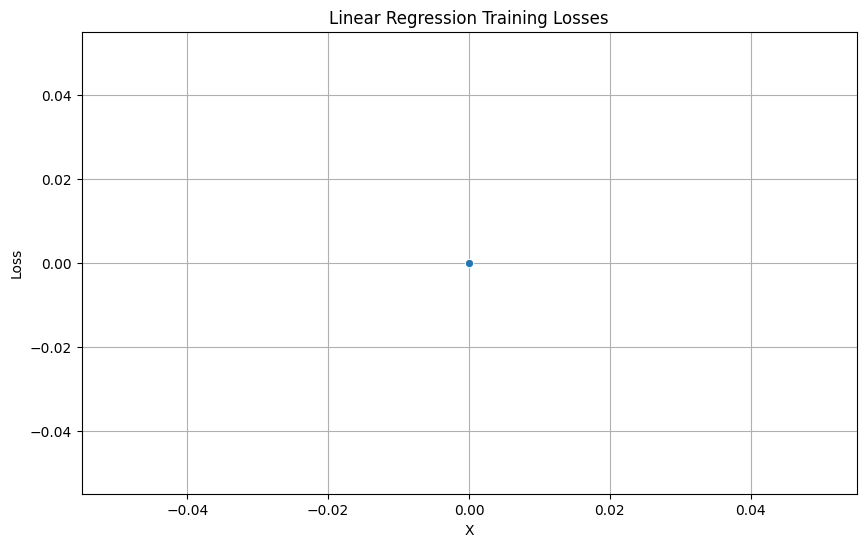

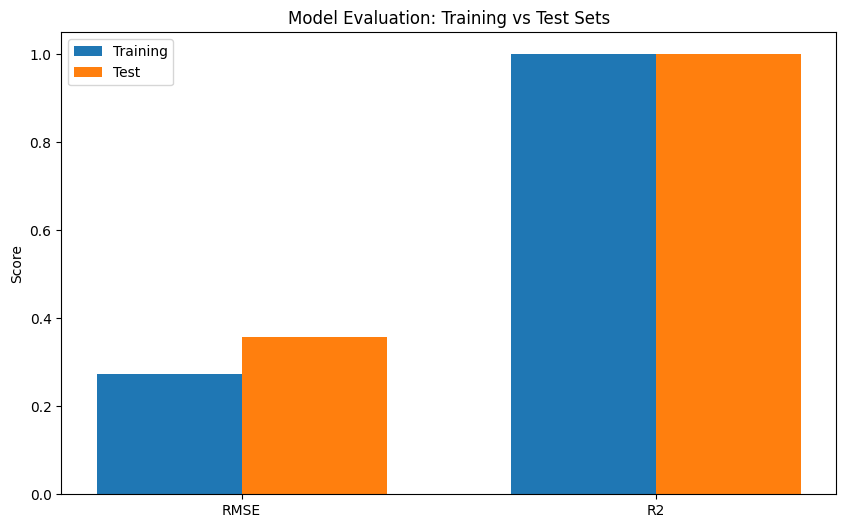

In [ ]:
model = LinearRegressionModel()
model.train(scaled_train_df)
model.predict(scaled_train_df, scaled_test_df)
model.evaluate_rmse()
model.evaluate_r2()

model.show_losses()
model.draw_bar_chart()